# Miniproyecto 2: Machine Learning con Valor
#### **Curso:** Introducción a Minería de Datos y Machine Learning

---

**¡Felicidades por tu excelente trabajo en el MP1!**

Tu labor en el preprocesamiento de la base de datos ha causado un gran impacto en **AMAZOFF**.

El equipo de Customer Experience ha quedado impresionado con tu habilidad para transformar datos sucios en información
útil y ahora quieren aprovechar tus talentos para enfrentar un nuevo desafío.

Nos han pedido desarrollar un **Predictor de Ratings de Pedidos** utilizando los datos preprocesados de ratings de
pedidos de nuestra plataforma de e-commerce.

In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

# Pauta de Evaluación

Este MP2 está enfocado en responder preguntas de negocio relevantes para **AMAZOFF**.

### Preguntas de Negocio

1. (15 puntos) El equipo necesita extraer la máxima información de los datos. ¿Cómo modificarías la base de datos para ser usada con modelos de ML?
2. (15 puntos) ¡Wow! Gran *feature engineering*. Toca armar tu set para entrenar el modelo. ¿Podrías generar gráficas para el equipo de Customer Experience que expliquen mejor los datos nuevos? ¡No olvides explicarlas!
3. (10 puntos) Dicen que se pueden encontrar patrones en tus datos de entrenamiento. ¿Qué patrones encuentras en los pedidos? ¿Cómo pueden ser de utilidad para mejorar las ventas de AMAZOFF?
4. (25 puntos) ¡Viva el ML! Toca predecir la satisfacción del cliente. ¿Es posible predecir bien el `rating_class`?
5. (20 puntos) El equipo de Customer Experience dice que un solo modelo no es suficiente. ¿Podrías implementar otro?
6. (15 puntos) ¡Dos modelos! Eso es genial. ¿Qué modelo funcionó peor? ¿Si utilizas PCA podría mejor?

### Tener en consideración:

En caso de que el código esté bien, pero no se responda (usando celdas de texto) la pregunta de negocio (sección **Explicación**), **se asignará máximo la mitad de puntos** de esa pregunta.

El miniproyecto está diseñado para completar código. Suba el notebook solo con el código para responder la pregunta de negocio.

> # ¡NO OLVIDES GUARDAR Y SUBIR EL NOTEBOOK A LA PLATAFORMA CUANDO TERMINES! FORMATO .ipynb

# Preámbulo

**¡Cuidado!** En esta sección solo puedes modificar la sección de PÁRAMETROS.

In [2]:
# ¡No modificar esta celda! No está permitido usar librerías adicionales.

# Association Rules
from mlxtend.frequent_patterns import apriori, association_rules

# Machine Learning
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA

# General Data Science
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [3]:
# Esta configuración permite que los dataframes se muestren completos.
pd.set_option('display.max_columns', None)

In [4]:
# PARÁMETROS (puedes modificar esta sección)

DATA_PATH = 'ecommerce.csv' # Si tienes el archivo en otro lugar, cámbialo.
RANDOM_STATE = 0 # ¡Cámbialo a tu número favorito!

In [5]:
# ¡No modificar! Esta celda se encarga de cargar los datos.
df = pd.read_csv(DATA_PATH)
df.purchased = pd.to_datetime(df.purchased)
df.delivered = pd.to_datetime(df.delivered)
df.estimated_delivery = pd.to_datetime(df.estimated_delivery)
print(f'{df.shape[0]} rows x {df.shape[1]} columns')
df.head(5)

63606 rows x 14 columns


,order,product,seller,customer,city,state,category,price,shipping,payment,purchased,delivered,estimated_delivery,rating
0,0,0,0,0,unknown,SP,health,223.51,84.65,credit card,2017-10-22 18:57:54,2017-10-26 22:19:52,2017-11-09 12:00:00,1.0
1,1,1,1,1,unknown,RJ,health,170.80,23.79,credit card,2018-06-20 21:40:31,2018-07-03 22:51:22,2018-07-24 12:00:00,4.5
2,2,2,2,2,unknown,SP,technology,64.40,17.38,credit card,2018-02-16 16:19:31,2018-02-27 01:29:50,2018-03-08 12:00:00,3.5
3,3,1,3,3,uberlandia,MG,technology,264.50,30.72,credit card,2018-08-18 18:04:29,2018-08-27 20:03:51,2018-09-19 12:00:00,3.0
4,4,3,4,4,unknown,SP,technology,779.90,30.66,credit card,2017-12-22 16:44:04,2018-01-05 19:22:49,2018-01-18 12:00:00,2.5


In [6]:
# ¿Cuántos valores únicos hay en cada columna?
for col in df.columns:
    print(f'{col}: {df[col].nunique()} unique values')

order: 63606 unique values
product: 18 unique values
seller: 25 unique values
customer: 63606 unique values
city: 26 unique values
state: 5 unique values
category: 5 unique values
price: 4433 unique values
shipping: 4849 unique values
payment: 2 unique values
purchased: 53475 unique values
delivered: 53496 unique values
estimated_delivery: 433 unique values
rating: 9 unique values


In [7]:
df.dtypes

order                          int64
product                        int64
seller                         int64
customer                       int64
city                          object
state                         object
category                      object
price                        float64
shipping                     float64
payment                       object
purchased             datetime64[ns]
delivered             datetime64[ns]
estimated_delivery    datetime64[ns]
rating                       float64
dtype: object

In [8]:
df.city.unique()

array(['unknown', 'uberlandia', 'guarulhos', 'sao paulo', 'sao goncalo',
       'belo horizonte', 'curitiba', 'porto alegre', 'rio de janeiro',
       'sao bernardo do campo', 'campinas', 'caxias do sul', 'cascavel',
       'niteroi', 'duque de caxias', 'londrina', 'nova iguacu', 'maringa',
       'contagem', 'santo andre', 'juiz de fora', 'ponta grossa',
       'pelotas', 'santa maria', 'canoas', 'uberaba'], dtype=object)

In [9]:
df.state.unique()

array(['SP', 'RJ', 'MG', 'RS', 'PR'], dtype=object)

In [10]:
df.category.unique()

array(['health', 'technology', 'fashion', 'toys', 'sports'], dtype=object)

In [11]:
df.payment.unique()

array(['credit card', 'other'], dtype=object)

In [12]:
print (f"{np.min(df.purchased)} - {np.max(df.purchased)}")

2016-10-03 09:44:50 - 2018-08-29 14:52:00


In [13]:
print (f"{np.min(df.delivered)} - {np.max(df.delivered)}")

2016-10-11 14:46:49 - 2018-10-02 00:18:50


In [14]:
print (f"{np.min(df.estimated_delivery)} - {np.max(df.estimated_delivery)}")

2016-10-27 12:00:00 - 2018-10-25 12:00:00


In [15]:
df.rating.unique()

array([1. , 4.5, 3.5, 3. , 2.5, 4. , 2. , 5. , 1.5])

# 1. El equipo necesita extraer la máxima información de los datos. ¿Cómo modificarías la base de datos para ser usada con modelos de ML?

⁉️ **Consideración:** La última celda de esta sección es la de cálculo de `rating_class`, mantener el orden. Agregar las celdas para modificar
los datos, antes de esta. No olvides modificar el código para calcular la clase de rating.

ℹ️ **HINT:** Utiliza una celda para cada columna. ¿Qué columnas no sirven? ¿Qué columnas necesito que sean números? ¿Nuevas columnas?

📖 **Referencia Externa:** [Feature Engineering](https://www.freecodecamp.org/news/feature-engineering-techniques-for-structured-data/).

---

✅ **Explicación:**

Se lleva a cabo una transformación de datos, desde una forma no numérica a numérica, esto es, a valores enteros. Tales nuevos valores facilitarán el entrenamiento para el aprendizaje automático, que permitirá a la máquina hacer una mejor clasificación a la hora de hacer, por parte de ésta, una predicción sobre los datos que se le suministren. Para hacer esta transformación se aplica un criterio binario 0 ó 1, para la mayoría de las características, para indicar la presencia (1) o ausencia (0) de una determinada feature. Se aplica este criterio dada la imposibilidad de establecer un valor cuantificable que indique la distancia entre dos o más características de tipo string. Distinto es el caso de las fechas, en el que se toma como valor numérico, los nanosegundos correspondientes a cada una.

In [16]:
###City: array(['unknown', 'uberlandia', 'guarulhos', 'sao paulo', 'sao goncalo',
###    'belo horizonte', 'curitiba', 'porto alegre', 'rio de janeiro',
###    'sao bernardo do campo', 'campinas', 'caxias do sul', 'cascavel',
###    'niteroi', 'duque de caxias', 'londrina', 'nova iguacu', 'maringa',
###    'contagem', 'santo andre', 'juiz de fora', 'ponta grossa',
###    'pelotas', 'santa maria', 'canoas', 'uberaba'], dtype=object)
df["is_unknown"] = (df["city"] == "unknown").astype(int)
df["is_uberlandia"] = (df["city"] == "uberlandia").astype(int)
df["is_guarulhos"] = (df["city"] == "guarulhos").astype(int)
df["is_sao_paulo"] = (df["city"] == "sao paulo").astype(int)
df["is_sao_goncalo"] = (df["city"] == "sao goncalo").astype(int)
df["is_belo_horizonte"] = (df["city"] == "belo horizonte").astype(int)
df["is_curitiba"] = (df["city"] == "curitiba").astype(int)
df["is_porto_alegre"] = (df["city"] == "porto alegre").astype(int)
df["is_rio_de_janeiro"] = (df["city"] == "rio de janeiro").astype(int)
df["is_sao_bernardo_do_campo"] = (df["city"] == "sao bernardo do campo").astype(int)
df["is_campinas"] = (df["city"] == "campinas").astype(int)
df["is_caxias_do_sul"] = (df["city"] == "caxias do sul").astype(int)
df["is_cascavel"] = (df["city"] == "cascavel").astype(int)
df["is_niteroi"] = (df["city"] == "niteroi").astype(int)
df["is_duque_de_caxias"] = (df["city"] == "duque de caxias").astype(int)
df["is_londrina"] = (df["city"] == "londrina").astype(int)
df["is_nova_iguacu"] = (df["city"] == "nova iguacu").astype(int)
df["is_maringa"] = (df["city"] == "maringa").astype(int)
df["is_contagem"] = (df["city"] == "contagem").astype(int)
df["is_santo_andre"] = (df["city"] == "santo andre").astype(int)
df["is_juiz_de_fora"] = (df["city"] == "juiz de fora").astype(int)
df["is_ponta_grossa"] = (df["city"] == "ponta grossa").astype(int)
df["is_pelotas"] = (df["city"] == "pelotas").astype(int)
df["is_santa_maria"] = (df["city"] == "santa maria").astype(int)
df["is_canoas"] = (df["city"] == "canoas").astype(int)
df["is_uberaba"] = (df["city"] == "uberaba").astype(int)

In [17]:
###State: array(['SP', 'RJ', 'MG', 'RS', 'PR'], dtype=object)
df["is_SP"] = (df["state"] == "SP").astype(int)
df["is_RJ"] = (df["state"] == "RJ").astype(int)
df["is_MG"] = (df["state"] == "MG").astype(int)
df["is_RS"] = (df["state"] == "RS").astype(int)
df["is_PR"] = (df["state"] == "PR").astype(int)

In [18]:
###Category: array(['health', 'technology', 'fashion', 'toys', 'sports'], dtype=object)
df["is_health"] = (df["category"] == "health").astype(int)
df["is_technology"] = (df["category"] == "technology").astype(int)
df["is_fashion"] = (df["category"] == "fashion").astype(int)
df["is_toys"] = (df["category"] == "toys").astype(int)
df["is_sports"] = (df["category"] == "sports").astype(int)

In [19]:
###Prices:
df["total_price"] = df["price"] + df["shipping"]

std_scaler = StandardScaler()
df["price_scaled"] = std_scaler.fit_transform(df[["price"]])
df["shipping_scaled"] = std_scaler.fit_transform(df[["shipping"]])
df["total_price_scaled"] = std_scaler.fit_transform(df[["total_price"]])

df["price_shipping_rate"] = df["price"] / df["total_price"]
df["expensive_shipping"] = (df["shipping_scaled"] > 0).astype(int)

In [20]:
###Payment: array(['credit card', 'other'], dtype=object)
df["is_credit_card"] = (df["payment"] == "credit card").astype(int)

In [21]:
###Fechas:
df["int_dtpurchased"] = np.int64(df["purchased"])
df["int_dtdelivered"] = np.int64(df["delivered"])
df["int_dtestimated_delivery"] = np.int64(df["estimated_delivery"])

In [22]:
###Rating:
df["std_rating"] = np.int64(df["rating"]*2)

In [23]:
df.head(3)

,order,product,seller,customer,city,state,category,price,shipping,payment,purchased,delivered,estimated_delivery,rating,is_unknown,is_uberlandia,is_guarulhos,is_sao_paulo,is_sao_goncalo,is_belo_horizonte,is_curitiba,is_porto_alegre,is_rio_de_janeiro,is_sao_bernardo_do_campo,is_campinas,is_caxias_do_sul,is_cascavel,is_niteroi,is_duque_de_caxias,is_londrina,is_nova_iguacu,is_maringa,is_contagem,is_santo_andre,is_juiz_de_fora,is_ponta_grossa,is_pelotas,is_santa_maria,is_canoas,is_uberaba,is_SP,is_RJ,is_MG,is_RS,is_PR,is_health,is_technology,is_fashion,is_toys,is_sports,total_price,price_scaled,shipping_scaled,total_price_scaled,price_shipping_rate,expensive_shipping,is_credit_card,int_dtpurchased,int_dtdelivered,int_dtestimated_delivery,std_rating
0,0,0,0,0,unknown,SP,health,223.51,84.65,credit card,2017-10-22 18:57:54,2017-10-26 22:19:52,2017-11-09 12:00:00,1.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,308.16,-0.211818,1.081507,-0.138344,0.725305,1,1,1508698674000000000,1509056392000000000,1510228800000000000,2
1,1,1,1,1,unknown,RJ,health,170.80,23.79,credit card,2018-06-20 21:40:31,2018-07-03 22:51:22,2018-07-24 12:00:00,4.5,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,194.59,-0.306389,-0.530649,-0.341782,0.877743,0,1,1529530831000000000,1530658282000000000,1532433600000000000,9
2,2,2,2,2,unknown,SP,technology,64.40,17.38,credit card,2018-02-16 16:19:31,2018-02-27 01:29:50,2018-03-08 12:00:00,3.5,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,81.78,-0.497289,-0.700447,-0.543858,0.787479,0,1,1518797971000000000,1519694990000000000,1520510400000000000,7


Debido a que estaremos realizando clasificación, pasaremos `rating`de numérico a categórico. Deberás modificar `RATING_BINS`
y `RATING_LABELS` para seleccionar cómo realizar el *binning* de esta clase.

**Ejemplo:**
```python
    RATING_BINS = [0, 2, 3.5, 5]
    RATING_LABELS = ['low', 'medium', 'high']
```

In [24]:
# Modifica RATING_BINS y RATING_LABELS según consideres.
RATING_BINS = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
RATING_LABELS = ['extreme low', 'very low', 'low', 'low medium', 'medium', 'high medium', 'high', 'very high', 'extreme high']

################################################################################

# ¡No modificar! Este código se encarga de crear la columna rating_class.
df['rating_class'] = pd.cut(df['rating'], bins=RATING_BINS, labels=RATING_LABELS, include_lowest=True)
df.value_counts(['rating', 'rating_class'], normalize=True, sort=False, dropna=False)

rating  rating_class
1.0     extreme low     0.262617
1.5     very low        0.062934
2.0     low             0.118322
2.5     low medium      0.077744
3.0     medium          0.137770
3.5     high medium     0.081046
4.0     high            0.045389
4.5     very high       0.124013
5.0     extreme high    0.090164
Name: proportion, dtype: float64

**¡Ten cuidado!** Debes intentar que tus `rating_class` no sean demasiado imbalancedas. Por ejemplo, que el 90% de los datos
sean *low*, 5% *medium* y 5% *high*. Es preferible algo como: 40% *low*, 30% *medium* y 30% *high*.

In [25]:
# ¡No modificar!
df.value_counts('rating_class', normalize=True, sort=False, dropna=False)

rating_class
extreme low     0.262617
very low        0.062934
low             0.118322
low medium      0.077744
medium          0.137770
high medium     0.081046
high            0.045389
very high       0.124013
extreme high    0.090164
Name: proportion, dtype: float64

# 2. ¡Wow! Gran *feature engineering*. Toca armar tu set para entrenar el modelo. ¿Podrías generar gráficas para el equipo de Customer Experience que expliquen mejor los datos nuevos? ¡No olvides explicarlas!

⁉️ **Consideración:** Modifica la lista de columnas a eliminar para el *train*. Debes de hacer por lo menos dos gráficos.

ℹ️ **HINT 1:** ¿Por qué tus gráficas aportan al equipo de Customer Experience? ¡Explica tus nuevas columnas! ¿No tienes? 😓

ℹ️ **HINT 2:** Un buen gráfico tiene título, *labels*, leyenda... ¡y mucho más!

📖 **Referencia Externa:** [Tutorial de Seaborn](https://www.datacamp.com/tutorial/seaborn-python-tutorial).

---

✅ **Explicación:**

- **Gráfico 1 (Gráfico de barras):** Un gráfico de barra se utiliza para mostrar la frecuencia o proporción de datos categóricos. Muestra los datos como barras rectangulares, donde la longitud de cada barra representa el valor de una categoría. Los gráficos de barras son los más adecuados para visualizar datos categóricos discretos **(Fuente: Visualización de datos Hecho Fácil, "Seaborn with Python: A Beginner’s Guide")**.

- **Gráfico 2 (Gráfico de dispersión):** Se utiliza un gráfico de dispersión para mostrar la conexión entre dos variables. Muestra un conjunto de puntos de datos, donde cada punto representa el valor de dos variables. Los gráficos de dispersión se utilizan con frecuencia para visualizar patrones y correlaciones en los datos. Son los más adecuados para los datos numéricos continuos **(Fuente: Visualización de datos Hecho Fácil, "Seaborn with Python: A Beginner’s Guide")**.

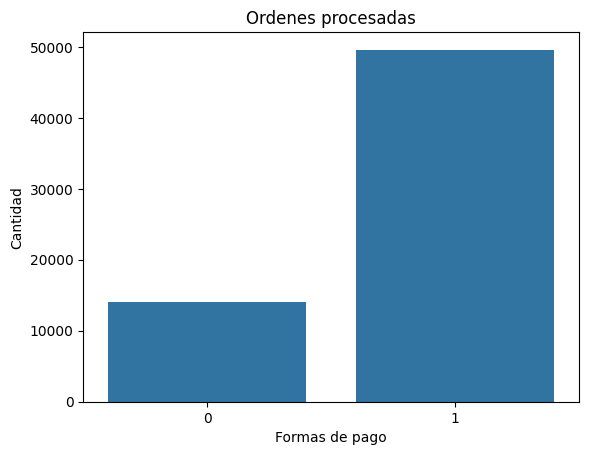

In [26]:
# Gráfico 1: GRÁFICO DE BARRAS DE ÓRDENES PROCESADAS SEGÚN FORMA DE PAGO (1=TARJETA DE CRÉDITO, 0=OTRA)

########################################################################################################################

# Filtrar los datos para incluir únicamente a los sobrevivientes:
lproductosvendidos = df["is_credit_card"].value_counts() #Lista de ordenes agrupadas segun forma de pago
# Crear un grafico de barra usando Seaborn:
sns.barplot(x=lproductosvendidos.index, y=lproductosvendidos.values)
# Establezca el título de la trama y etiquetas de eje:
plt.title("Ordenes procesadas")
plt.xlabel("Formas de pago")
plt.ylabel("Cantidad")
# Guardar figura:
plt.savefig("bar-plot.png")
# Mostrar la trama:
plt.show()

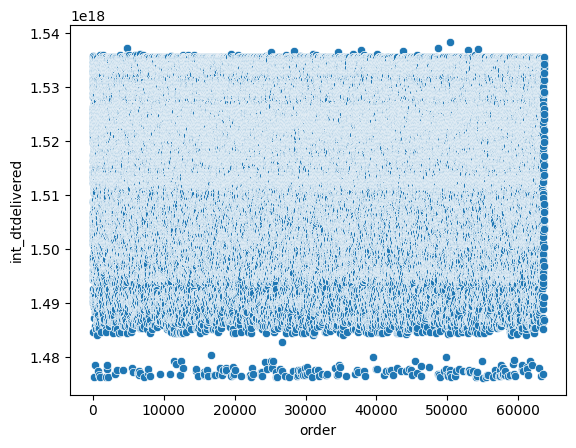

In [27]:
# Gráfico 2: GRÁFICO DE DISPERSIÓN DE LAS ÓRDENES VERSUS EL N° ASOCIADO A LA FECHA DE ENTREGA.

########################################################################################################################

# Crear una "parcela" de dispersión usando Seaborn:
sns.scatterplot(x="order", y="int_dtdelivered", data=df) #Relacion entre las ordenes y la fecha de entrega
# Guardar figura:
plt.savefig("scatterplot.png")
# Mostrar la trama:
plt.show()

In [28]:
df.head(3)

,order,product,seller,customer,city,state,category,price,shipping,payment,purchased,delivered,estimated_delivery,rating,is_unknown,is_uberlandia,is_guarulhos,is_sao_paulo,is_sao_goncalo,is_belo_horizonte,is_curitiba,is_porto_alegre,is_rio_de_janeiro,is_sao_bernardo_do_campo,is_campinas,is_caxias_do_sul,is_cascavel,is_niteroi,is_duque_de_caxias,is_londrina,is_nova_iguacu,is_maringa,is_contagem,is_santo_andre,is_juiz_de_fora,is_ponta_grossa,is_pelotas,is_santa_maria,is_canoas,is_uberaba,is_SP,is_RJ,is_MG,is_RS,is_PR,is_health,is_technology,is_fashion,is_toys,is_sports,total_price,price_scaled,shipping_scaled,total_price_scaled,price_shipping_rate,expensive_shipping,is_credit_card,int_dtpurchased,int_dtdelivered,int_dtestimated_delivery,std_rating,rating_class
0,0,0,0,0,unknown,SP,health,223.51,84.65,credit card,2017-10-22 18:57:54,2017-10-26 22:19:52,2017-11-09 12:00:00,1.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,308.16,-0.211818,1.081507,-0.138344,0.725305,1,1,1508698674000000000,1509056392000000000,1510228800000000000,2,extreme low
1,1,1,1,1,unknown,RJ,health,170.80,23.79,credit card,2018-06-20 21:40:31,2018-07-03 22:51:22,2018-07-24 12:00:00,4.5,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,194.59,-0.306389,-0.530649,-0.341782,0.877743,0,1,1529530831000000000,1530658282000000000,1532433600000000000,9,very high
2,2,2,2,2,unknown,SP,technology,64.40,17.38,credit card,2018-02-16 16:19:31,2018-02-27 01:29:50,2018-03-08 12:00:00,3.5,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,81.78,-0.497289,-0.700447,-0.543858,0.787479,0,1,1518797971000000000,1519694990000000000,1520510400000000000,7,high medium


In [29]:
# Modifica la lista de columnas a eliminar según consideres.

x = df.drop(
    columns=[
        # Agrega las columnas que consideres
        'order', 'product', 'seller', 'customer',
        'city', 'state', 'category', 'price', 'total_price','shipping', 'payment', 'purchased', 'delivered', 'estimated_delivery',
        'rating', 'rating_class'
    ]
)

########################################################################################################################

# ¡No modificar! Esta celda se encarga de dividir los datos en conjuntos de entrenamiento, validación y prueba.

y = df['rating_class']

x_train_val, x_test, y_train_val, y_test = train_test_split(x, y, test_size=0.2, shuffle=True, random_state=RANDOM_STATE)
x_train, x_val, y_train, y_val = train_test_split(x_train_val, y_train_val, test_size=0.2, shuffle=True, random_state=RANDOM_STATE)

print(f'Train: {x_train.shape[0]} rows')
print(f'Validation: {x_val.shape[0]} rows')
print(f'Test: {x_test.shape[0]} rows')

display(x_train.head(5))

Train: 40707 rows
Validation: 10177 rows
Test: 12722 rows


,is_unknown,is_uberlandia,is_guarulhos,is_sao_paulo,is_sao_goncalo,is_belo_horizonte,is_curitiba,is_porto_alegre,is_rio_de_janeiro,is_sao_bernardo_do_campo,is_campinas,is_caxias_do_sul,is_cascavel,is_niteroi,is_duque_de_caxias,is_londrina,is_nova_iguacu,is_maringa,is_contagem,is_santo_andre,is_juiz_de_fora,is_ponta_grossa,is_pelotas,is_santa_maria,is_canoas,is_uberaba,is_SP,is_RJ,is_MG,is_RS,is_PR,is_health,is_technology,is_fashion,is_toys,is_sports,price_scaled,shipping_scaled,total_price_scaled,price_shipping_rate,expensive_shipping,is_credit_card,int_dtpurchased,int_dtdelivered,int_dtestimated_delivery,std_rating
12599,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,-0.490650,1.081507,-0.416729,0.445827,1,1,1496261620000000000,1496753570000000000,1498478400000000000,2
62633,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,-0.004609,-0.385221,-0.030652,0.920495,0,1,1517329962000000000,1519762369000000000,1519214400000000000,2
4875,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,-0.492803,-0.754221,-0.543016,0.813374,0,1,1525368394000000000,1526040677000000000,1527508800000000000,4
59977,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,-0.553985,2.833793,-0.361468,0.178649,1,1,1523810895000000000,1524248569000000000,1525867200000000000,2
18343,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,-0.564570,-0.122709,-0.571963,0.407021,0,1,1534774555000000000,1535474527000000000,1535716800000000000,3


In [30]:
display(y_train.head(5))

12599    extreme low
62633    extreme low
4875             low
59977    extreme low
18343       very low
Name: rating_class, dtype: category
Categories (9, object): ['extreme low' < 'very low' < 'low' < 'low medium' ... 'high medium' < 'high' < 'very high' < 'extreme high']

# 3. Dicen que se pueden encontrar patrones en tus datos de entrenamiento. ¿Qué patrones encuentras en los pedidos? ¿Cómo pueden ser de utilidad para mejorar las ventas de AMAZOFF?

⁉️ **Consideración:** Utiliza reglas de asociación para encontrar reglas útiles para nuevas estrategias de venta. Explica los parámetros y métricas de tu modelo.

ℹ️ **HINT 1:** ¿Qué librería se importó en el inicio? Cuidado, ¡solo datos binarios!

ℹ️ **HINT 2:** De las principales reglas encontradas... ¿cómo implementarías una estrategia de venta/marketing utilizando esta información?

📖 **Referencia Externa:** [Documentación de mlxtend](https://rasbt.github.io/mlxtend/user_guide/frequent_patterns/apriori/).

---

✅ **Explicación:**

Para hallar reglas de asociación se utiliza el algoritmo Apriori. En primer lugar se ocupa un dataframe que no incluya las columnas no binarias de la forma 0 ó 1, transformándolas posteriormente a su valor booleano respectivo, requerido por el método apriori() de la librería mlxtend. Se ocupa un umbral de 0.5 para efectos de discriminar sólo aquellas reglas que cumplan con dicha frecuencia relativa (soporte) mínima. Finalmente se muestran las transacciones que cumplan con dichas reglas encontradas.

In [31]:
binary_x_train = x_train.drop(
    columns=[
        # Agrega las columnas que consideres
        'int_dtpurchased', 'int_dtdelivered', 'int_dtestimated_delivery',
        'price_scaled', 'shipping_scaled', 'total_price_scaled', 'price_shipping_rate', 'std_rating'
    ]
).astype(bool)

frequent_itemsets = apriori(binary_x_train, min_support=0.5, use_colnames=True) #Definimos un umbral de 1/2
frequent_itemsets

,support,itemsets
0,0.508045,(is_unknown)
1,0.547523,(is_SP)
2,0.780578,(is_credit_card)


In [32]:
rules = df[df["is_unknown"]==1][df["is_SP"]==1][df["is_credit_card"]==1]
rules

C:\Users\fmart\AppData\Local\Temp\ipykernel_10708\2031873675.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  rules = df[df["is_unknown"]==1][df["is_SP"]==1][df["is_credit_card"]==1]
C:\Users\fmart\AppData\Local\Temp\ipykernel_10708\2031873675.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  rules = df[df["is_unknown"]==1][df["is_SP"]==1][df["is_credit_card"]==1]


,order,product,seller,customer,city,state,category,price,shipping,payment,purchased,delivered,estimated_delivery,rating,is_unknown,is_uberlandia,is_guarulhos,is_sao_paulo,is_sao_goncalo,is_belo_horizonte,is_curitiba,is_porto_alegre,is_rio_de_janeiro,is_sao_bernardo_do_campo,is_campinas,is_caxias_do_sul,is_cascavel,is_niteroi,is_duque_de_caxias,is_londrina,is_nova_iguacu,is_maringa,is_contagem,is_santo_andre,is_juiz_de_fora,is_ponta_grossa,is_pelotas,is_santa_maria,is_canoas,is_uberaba,is_SP,is_RJ,is_MG,is_RS,is_PR,is_health,is_technology,is_fashion,is_toys,is_sports,total_price,price_scaled,shipping_scaled,total_price_scaled,price_shipping_rate,expensive_shipping,is_credit_card,int_dtpurchased,int_dtdelivered,int_dtestimated_delivery,std_rating,rating_class
0,0,0,0,0,unknown,SP,health,223.51,84.65,credit card,2017-10-22 18:57:54,2017-10-26 22:19:52,2017-11-09 12:00:00,1.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,308.16,-0.211818,1.081507,-0.138344,0.725305,1,1,1508698674000000000,1509056392000000000,1510228800000000000,2,extreme low
2,2,2,2,2,unknown,SP,technology,64.40,17.38,credit card,2018-02-16 16:19:31,2018-02-27 01:29:50,2018-03-08 12:00:00,3.5,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,81.78,-0.497289,-0.700447,-0.543858,0.787479,0,1,1518797971000000000,1519694990000000000,1520510400000000000,7,high medium
4,4,3,4,4,unknown,SP,technology,779.90,30.66,credit card,2017-12-22 16:44:04,2018-01-05 19:22:49,2018-01-18 12:00:00,2.5,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,810.56,0.786441,-0.348665,0.761602,0.962174,0,1,1513961044000000000,1515180169000000000,1516276800000000000,5,low medium
6,6,1,6,6,unknown,SP,fashion,1534.90,66.90,credit card,2018-02-23 14:49:39,2018-04-02 14:12:50,2018-03-15 12:00:00,1.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1601.80,2.141040,0.611317,2.178946,0.958234,1,1,1519397379000000000,1522678370000000000,1521115200000000000,2,extreme low
11,11,1,8,11,unknown,SP,technology,222.98,31.89,credit card,2018-05-02 22:52:10,2018-05-09 23:48:32,2018-05-18 12:00:00,2.5,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,254.87,-0.212769,-0.316083,-0.233802,0.874877,0,1,1525301530000000000,1525909712000000000,1526644800000000000,5,low medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63583,63583,6,8,63583,unknown,SP,sports,420.07,38.63,credit card,2018-04-25 15:21:49,2018-04-30 20:42:04,2018-05-14 12:00:00,2.5,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,458.70,0.140844,-0.137543,0.131317,0.915784,0,1,1524669709000000000,1525120924000000000,1526299200000000000,5,low medium
63587,63587,4,8,63587,unknown,SP,fashion,24.79,33.90,credit card,2017-10-17 16:43:56,2017-10-19 20:09:24,2017-10-27 12:00:00,1.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,58.69,-0.568356,-0.262839,-0.585219,0.422389,0,1,1508258636000000000,1508443764000000000,1509105600000000000,2,extreme low
63595,63595,0,21,63595,unknown,SP,technology,170.70,41.41,credit card,2017-09-23 10:33:21,2017-10-01 12:09:52,2017-10-23 12:00:00,2.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,212.11,-0.306568,-0.063902,-0.310398,0.804771,0,1,1506162801000000000,1506859792000000000,1508760000000000000,4,low
63597,63597,6,0,63597,unknown,SP,health,26.20,93.65,credit card,2017-07-10 09:03:58,2017-07-18 13:04:24,2017-07-28 12:00:00,1.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,119.85,-0.565826,1.319914,-0.475663,0.218607,1,1,1499677438000000000,1500383064000000000,1501243200000000000,2,extreme low


# 4. ¡Viva el ML! Toca predecir la satisfacción del cliente. ¿Es posible predecir bien el `rating_class`?

⁉️ **Consideraciones:**

- Elige tres sets de hiperparámetros **diferentes** para los tres modelos de clasificación de *Random Forest*.
- Debes modificar al menos 4 hiperparámetros. No cuentes `random_state`ni `n_jobs`.
- Tus sets de hiperparámetros deben pasar la prueba de *overfitting* y *underfitting*.
- Utiliza los resultados de la validación para elegir tus hiperparámetros, no los del testeo.
- No olvides interpretar tus resultados e intenta relacionarlos a los intereses de **AMAZOFF** si es posible.

ℹ️ **HINT:** El ML es un proceso iterativo, a veces si es que no funcionan bien tus resultados debes de volver a empezar.

📖 **Referencia Externa:** [RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html).

---

✅ **Explicación:**

- **Justifica tus hiperpámetros:** Se ocupan los parámetros n_estimators (número de árboles), max_depth (profundidad del árbol), max_features (número de características a considerar para buscar la mejor división) y criterion (función para medir la calidad de una división, que puede ser Gini, Entropy o LogLoss). Se utilizan diferentes combinaciones de estos parámetros para cada uno de los tres bosques aleatorios, con el fin de medir cual de ellos es el de mayor rendimiento.
- **¿Hay *overfitting* o *underfitting*:** Los parámetros evaluados muestran un infraajuste (underfitting) en el caso del primero y el último de los bosques aleatorios utilizados, que demostraron tener un menor rendimiento en comparación con el segundo bosque aleatorio que fue el de mayor exactitud, aunque fue también el de mayor tiempo de ejecución con 50.9 segundos en Google Colabs.
- **Resultados de Validación:** El segundo bosque aleatorio mostró una mayor exactitud (accuracy) con 0.95 versus 0.58 y 0.91 del primer y último bosque respectivamente.
- **Resultados de Testeo:** Con los datos de testeo los bosques alatorios obtuvieron una axactitud predictiva de 0.57, 0.95 y 0.91 respectivamente.
- **¿Es posible predecir bien el `rating_class`:** Con los datos suministrados se observó un buen nivel predictivo, con 0.95 de exactitud para el segundo bosque aleatorio evaluado.

In [33]:
x_train.head(1)

,is_unknown,is_uberlandia,is_guarulhos,is_sao_paulo,is_sao_goncalo,is_belo_horizonte,is_curitiba,is_porto_alegre,is_rio_de_janeiro,is_sao_bernardo_do_campo,is_campinas,is_caxias_do_sul,is_cascavel,is_niteroi,is_duque_de_caxias,is_londrina,is_nova_iguacu,is_maringa,is_contagem,is_santo_andre,is_juiz_de_fora,is_ponta_grossa,is_pelotas,is_santa_maria,is_canoas,is_uberaba,is_SP,is_RJ,is_MG,is_RS,is_PR,is_health,is_technology,is_fashion,is_toys,is_sports,price_scaled,shipping_scaled,total_price_scaled,price_shipping_rate,expensive_shipping,is_credit_card,int_dtpurchased,int_dtdelivered,int_dtestimated_delivery,std_rating
12599,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,-0.49065,1.081507,-0.416729,0.445827,1,1,1496261620000000000,1496753570000000000,1498478400000000000,2


In [34]:
%%time

# Debes de modificar al menos 4 parámetros, sin contar random_state y n_jobs.

rf1 = RandomForestClassifier(
    n_estimators=200,           #Num. arboles, 100 por defecto
    max_depth=5,                #Profundidad del arbol
    max_features=3,             #Num. maximo de caracteristicas a considerar
    criterion="entropy",        #Criterio Entropia, por defecto: Gini
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf1.fit(x_train, y_train)

CPU times: total: 7.67 s
Wall time: 2.7 s


RandomForestClassifier(criterion='entropy', max_depth=5, max_features=3,
                       n_estimators=200, n_jobs=-1, random_state=0)

In [35]:
%%time

# Debes de modificar al menos 4 parámetros, sin contar random_state y n_jobs.

rf2 = RandomForestClassifier(
    n_estimators=500,           #Num. arboles, 100 por defecto
    max_depth=10,               #Profundidad del arbol
    max_features=6,             #Num. maximo de caracteristicas a considerar
    criterion="log_loss",       #Criterio Log Loss, por defecto: Gini
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf2.fit(x_train, y_train)

CPU times: total: 1min 13s
Wall time: 19.5 s


RandomForestClassifier(criterion='log_loss', max_depth=10, max_features=6,
                       n_estimators=500, n_jobs=-1, random_state=0)

In [36]:
%%time

# Debes de modificar al menos 4 parámetros, sin contar random_state y n_jobs.

rf3 = RandomForestClassifier(
    n_estimators=400,           #Num. arboles, 100 por defecto
    max_depth=8,                #Profundidad del arbol
    max_features=6,             #Num. maximo de caracteristicas a considerar
    criterion="entropy",        #Criterio Entropia, por defecto: Gini
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf3.fit(x_train, y_train)

CPU times: total: 50.9 s
Wall time: 13.5 s


RandomForestClassifier(criterion='entropy', max_depth=8, max_features=6,
                       n_estimators=400, n_jobs=-1, random_state=0)

In [37]:
# ¡No modificar! Esta celda se encarga de evaluar los modelos y mostrar los resultados.

y_val_pred1 = rf1.predict(x_val)
y_val_pred2 = rf2.predict(x_val)
y_val_pred3 = rf3.predict(x_val)

print('[Random Forest] Check Overfitting with Accuracy')
print(f'RF1: train={accuracy_score(y_train, rf1.predict(x_train)):.4f} val={accuracy_score(y_val, y_val_pred1):.4f}')
print(f'RF2: train={accuracy_score(y_train, rf2.predict(x_train)):.4f} val={accuracy_score(y_val, y_val_pred2):.4f}')
print(f'RF3: train={accuracy_score(y_train, rf3.predict(x_train)):.4f} val={accuracy_score(y_val, y_val_pred3):.4f}')

[Random Forest] Check Overfitting with Accuracy
RF1: train=0.5758 val=0.5770
RF2: train=0.9655 val=0.9519
RF3: train=0.9171 val=0.9096


In [38]:
# ¡No modificar! Esta celda se encarga de mostrar los resultados en el set de validación.

print('[Random Forest] Validation Classification Report')
print('#'*80)
print('RF1')
print(classification_report(y_val, y_val_pred1))
print('#'*80)
print('RF2')
print(classification_report(y_val, y_val_pred2))
print('#'*80)
print('RF3')
print(classification_report(y_val, y_val_pred3))

[Random Forest] Validation Classification Report
################################################################################
RF1


C:\Users\fmart\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\fmart\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\fmart\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

              precision    recall  f1-score   support

extreme high       0.73      0.84      0.78       924
 extreme low       0.51      1.00      0.68      2653
        high       0.00      0.00      0.00       462
 high medium       0.00      0.00      0.00       872
         low       0.74      0.23      0.35      1223
  low medium       0.00      0.00      0.00       752
      medium       0.58      0.86      0.69      1414
   very high       0.64      0.76      0.69      1263
    very low       0.00      0.00      0.00       614

    accuracy                           0.58     10177
   macro avg       0.36      0.41      0.35     10177
weighted avg       0.45      0.58      0.47     10177

################################################################################
RF2
              precision    recall  f1-score   support

extreme high       0.99      0.88      0.93       924
 extreme low       0.96      1.00      0.98      2653
        high       1.00      0.55      0.71    

In [39]:
# ¡Completa el código! Esta celda se encarga de evaluar los modelos en el set de testeo y mostrar los resultados.

y_pred_rf1 = rf1.predict(x_test)
y_pred_rf2 = rf2.predict(x_test)
y_pred_rf3 = rf3.predict(x_test)

print('[Random Forest] Test Classification Report')
print('#'*80)
print('RF1')
print(classification_report(y_test, y_pred_rf1))
print('#'*80)
print('RF2')
print(classification_report(y_test, y_pred_rf2))
print('#'*80)
print('RF3')
print(classification_report(y_test, y_pred_rf3))

[Random Forest] Test Classification Report
################################################################################
RF1
              precision    recall  f1-score   support

extreme high       0.72      0.83      0.77      1145
 extreme low       0.52      1.00      0.68      3368
        high       0.00      0.00      0.00       594
 high medium       0.00      0.00      0.00      1035
         low       0.71      0.21      0.33      1444
  low medium       0.00      0.00      0.00       976
      medium       0.57      0.85      0.68      1746
   very high       0.63      0.75      0.68      1573
    very low       0.00      0.00      0.00       841

    accuracy                           0.57     12722
   macro avg       0.35      0.40      0.35     12722
weighted avg       0.44      0.57      0.47     12722

################################################################################
RF2


C:\Users\fmart\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\fmart\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\fmart\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

              precision    recall  f1-score   support

extreme high       0.99      0.88      0.93      1145
 extreme low       0.95      1.00      0.98      3368
        high       1.00      0.50      0.67       594
 high medium       0.95      0.98      0.96      1035
         low       0.97      1.00      0.99      1444
  low medium       1.00      0.98      0.99       976
      medium       0.99      1.00      0.99      1746
   very high       0.81      1.00      0.89      1573
    very low       1.00      0.77      0.87       841

    accuracy                           0.95     12722
   macro avg       0.96      0.90      0.92     12722
weighted avg       0.95      0.95      0.94     12722

################################################################################
RF3
              precision    recall  f1-score   support

extreme high       0.98      0.88      0.92      1145
 extreme low       0.91      1.00      0.95      3368
        high       1.00      0.06      0.12    

# 5. El equipo de Customer Experience dice que un solo modelo no es suficiente. ¿Podrías implementar otro?

⁉️ **Consideración:** Utiliza otro modelo visto en clase, como *KNN* y repite todos los pasos de la pregunta 4. No utilices *Random Forest*.

ℹ️ **HINT 1:** No olvides elegir 3 set de hiperparámetros y analizar los resultados de validación y testeo.

ℹ️ **HINT 2:** Si utilizas un modelo no visto en clases, debes de explicar su funcionamiento para utilizarlo.

📖 **Referencia Externa:** [KNN](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html).

---

✅ **Explicación:** Se ocupa el algoritmo de KNN y se construyen 3 clasificadores con éste, variando sus parámetros de entrada.

- **Justifica tus hiperpámetros:** Se ocupan los parámetros de n_neighbors (num. de vecinos), weights (función de peso), algorithm (algoritmo a utilizar), leaf_size (tamaño de la hoja), n_jobs (num. de procesadores a ejecutar). Para efectos de las pruebas, se dejan fijos los 2 primeros, con los valores 30 y 'distance' respectivamente, y también los 2 últimos con los valores respectivos de 50 y -1 (todos los procesadores), y se varía el algoritmo a utilizar, ocupando BallTree, KDTree y fuerza bruta (Brute) en cada caso.
- **¿Hay *overfitting* o *underfitting*:** Se aprecia un subajuste (underfitting), dado el bajo rendimiento (precisión en torno al 30%) obtenido para los 3 clasificadores.
- **Resultados de Validación:** Se obtiene una precisión relativamente baja para los 3 clasificadores, con 0.31 para los 2 primeros y 0.3 para el último.
- **Resultados de Testeo:** Para el caso del testeo se obtiene una precisión de 0.3 para los 3 clasificadores.
- **¿Es posible predecir bien el `rating_class`:** El clasificador, con los parámetros evaluados, en general muestra una capacidad predictiva baja, de tan solo un 30%, para todas las combinaciones de parámetros evaluados.

In [40]:
x_train.head(1)

,is_unknown,is_uberlandia,is_guarulhos,is_sao_paulo,is_sao_goncalo,is_belo_horizonte,is_curitiba,is_porto_alegre,is_rio_de_janeiro,is_sao_bernardo_do_campo,is_campinas,is_caxias_do_sul,is_cascavel,is_niteroi,is_duque_de_caxias,is_londrina,is_nova_iguacu,is_maringa,is_contagem,is_santo_andre,is_juiz_de_fora,is_ponta_grossa,is_pelotas,is_santa_maria,is_canoas,is_uberaba,is_SP,is_RJ,is_MG,is_RS,is_PR,is_health,is_technology,is_fashion,is_toys,is_sports,price_scaled,shipping_scaled,total_price_scaled,price_shipping_rate,expensive_shipping,is_credit_card,int_dtpurchased,int_dtdelivered,int_dtestimated_delivery,std_rating
12599,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,-0.49065,1.081507,-0.416729,0.445827,1,1,1496261620000000000,1496753570000000000,1498478400000000000,2


In [41]:
y_train.head(5)

12599    extreme low
62633    extreme low
4875             low
59977    extreme low
18343       very low
Name: rating_class, dtype: category
Categories (9, object): ['extreme low' < 'very low' < 'low' < 'low medium' ... 'high medium' < 'high' < 'very high' < 'extreme high']

In [42]:
# Si usas un modelo no visto en clase: Descomenta e importa tu nuevo modelo de clasificación aquí.
# ¡No olvides agregar a tu explicación cómo funciona el modelo no visto en clase!

# from sklearn.

In [47]:
# Instancia tu modelo 1 aquí.

#%%time

# Clasificador KNN1:

kn1 = KNeighborsClassifier(
    n_neighbors=30,             #Num. de vecinos, 5 por defecto
    weights="distance",         #Funcion de peso (uniform ó distance), por defecto: Uniform
    algorithm="ball_tree",      #Algoritmo a utilizar (auto, ball_tree, kd_tree, brute), por defecto Auto
    leaf_size=50,               #Tamaño de la hoja que se pasa al algoritmo ball_tree o kd_tree, 30 por defecto
    n_jobs=-1                   #Todos los procesadores (-1)
)

kn1.fit(x_train, y_train)

KNeighborsClassifier(algorithm='ball_tree', leaf_size=50, n_jobs=-1,
                     n_neighbors=30, weights='distance')

In [49]:
# Instancia tu modelo 2 aquí.

#%%time

# Clasificador KNN2:

kn2 = KNeighborsClassifier(
    n_neighbors=30,             #Num. de vecinos, 5 por defecto
    weights="distance",         #Funcion de peso (uniform ó distance), por defecto: Uniform
    algorithm="kd_tree",        #Algoritmo a utilizar (auto, ball_tree, kd_tree, brute), por defecto Auto
    leaf_size=50,               #Tamaño de la hoja que se pasa al algoritmo ball_tree o kd_tree, 30 por defecto
    n_jobs=-1                   #Todos los procesadores (-1)
)

kn2.fit(x_train, y_train)

KNeighborsClassifier(algorithm='kd_tree', leaf_size=50, n_jobs=-1,
                     n_neighbors=30, weights='distance')

In [51]:
# Instancia tu modelo 3 aquí.

#%%time

# Clasificador KNN3:

kn3 = KNeighborsClassifier(
    n_neighbors=30,             #Num. de vecinos, 5 por defecto
    weights="distance",         #Funcion de peso (uniform ó distance), por defecto: Uniform
    algorithm="brute",          #Algoritmo a utilizar (auto, ball_tree, kd_tree, brute), por defecto Auto
    leaf_size=50,               #Tamaño de la hoja que se pasa al algoritmo ball_tree o kd_tree, 30 por defecto
    n_jobs=-1                   #Todos los procesadores (-1)
)

kn3.fit(x_train, y_train)

KNeighborsClassifier(algorithm='brute', leaf_size=50, n_jobs=-1, n_neighbors=30,
                     weights='distance')

In [52]:
# Revisa si hay overfitting (resultado de entrenamiento muy superior al de validación).
# Utiliza: `accuracy_score`.

# Esta celda se encarga de evaluar los modelos y mostrar los resultados:

y_val_pred1 = kn1.predict(x_val)
y_val_pred2 = kn2.predict(x_val)
y_val_pred3 = kn3.predict(x_val)

print('[KNN] Check Overfitting with Accuracy')
print(f'KN1: train={accuracy_score(y_train, kn1.predict(x_train)):.4f} val={accuracy_score(y_val, y_val_pred1):.4f}')
print(f'KN2: train={accuracy_score(y_train, kn2.predict(x_train)):.4f} val={accuracy_score(y_val, y_val_pred2):.4f}')
print(f'KN3: train={accuracy_score(y_train, kn3.predict(x_train)):.4f} val={accuracy_score(y_val, y_val_pred3):.4f}')

[KNN] Check Overfitting with Accuracy
KN1: train=1.0000 val=0.3073
KN2: train=1.0000 val=0.3073
KN3: train=0.9562 val=0.2985


In [53]:
# Imprime los resultados de tus modelos en el set de validación (classification_report).

# Esta celda se encarga de mostrar los resultados en el set de validación:

print('[KNN] Validation Classification Report')
print('#'*80)
print('KN1')
print(classification_report(y_val, y_val_pred1))
print('#'*80)
print('KN2')
print(classification_report(y_val, y_val_pred2))
print('#'*80)
print('KN3')
print(classification_report(y_val, y_val_pred3))

[KNN] Validation Classification Report
################################################################################
KN1
              precision    recall  f1-score   support

extreme high       0.40      0.35      0.37       924
 extreme low       0.35      0.61      0.44      2653
        high       0.14      0.06      0.08       462
 high medium       0.23      0.12      0.15       872
         low       0.29      0.24      0.26      1223
  low medium       0.20      0.12      0.15       752
      medium       0.26      0.24      0.25      1414
   very high       0.28      0.24      0.26      1263
    very low       0.14      0.05      0.08       614

    accuracy                           0.31     10177
   macro avg       0.26      0.23      0.23     10177
weighted avg       0.28      0.31      0.28     10177

################################################################################
KN2
              precision    recall  f1-score   support

extreme high       0.40      0.

In [54]:
# Imprime los resultados de tus modelos en el set de testeo (classification_report).

# Esta celda se encarga de evaluar los modelos en el set de testeo y mostrar los resultados:

y_pred_kn1 = kn1.predict(x_test)
y_pred_kn2 = kn2.predict(x_test)
y_pred_kn3 = kn3.predict(x_test)

print('[KNN] Test Classification Report')
print('#'*80)
print('KN1')
print(classification_report(y_test, y_pred_kn1))
print('#'*80)
print('KN2')
print(classification_report(y_test, y_pred_kn2))
print('#'*80)
print('KN3')
print(classification_report(y_test, y_pred_kn3))

[KNN] Test Classification Report
################################################################################
KN1
              precision    recall  f1-score   support

extreme high       0.39      0.35      0.37      1145
 extreme low       0.35      0.60      0.44      3368
        high       0.16      0.06      0.09       594
 high medium       0.19      0.11      0.14      1035
         low       0.24      0.22      0.23      1444
  low medium       0.20      0.10      0.13       976
      medium       0.26      0.25      0.26      1746
   very high       0.27      0.25      0.26      1573
    very low       0.18      0.06      0.09       841

    accuracy                           0.30     12722
   macro avg       0.25      0.22      0.22     12722
weighted avg       0.28      0.30      0.28     12722

################################################################################
KN2
              precision    recall  f1-score   support

extreme high       0.39      0.35    

# 6. ¡Dos modelos! Eso es genial. ¿Qué modelo funcionó peor? ¿Si utilizas PCA podría mejor?

⁉️ **Consideración:** Elige la combinación de modelo e hiperparámetros que peor se desempeño entre las preguntas 4 y 5. Aplica PCA con un número de componentes adecuado y corre los resultados otra vez.

ℹ️ **HINT:** ¿Cómo se elige el número de componentes? ¿Y ese gráfico para qué sirve?

📖 **Referencia Externa:** [PCA](https://www.baeldung.com/cs/pca).

---

✅ **Explicación:** Se ocupa el Random Forest con los parámetros de mejor rendimiento obtenido para el algoritmo.

- **¿Por qué elegiste ese número de componentes?** Una reducción de dimensionalidad puede facilitar el análisis por parte del clasificador. Se prueba con 3 componentes principales.
- **Resultados de Validación:** Se obtiene una precisión baja, de tan solo un 27%.
- **Resultados de Testeo:** Se obtiene también una precisión baja, de un 28%.
- **¿Mejoraron los resultados al usar PCA? ¿Por qué?** Con la reducción de dimensionalidad se observa un empeoramiento de la calidad predictiva del clasificador para el caso visto. La totalidad de los componentes de los datos suministrados parace ser determinante para establecer las reglas de asociación correspondientes a un rating en particular.

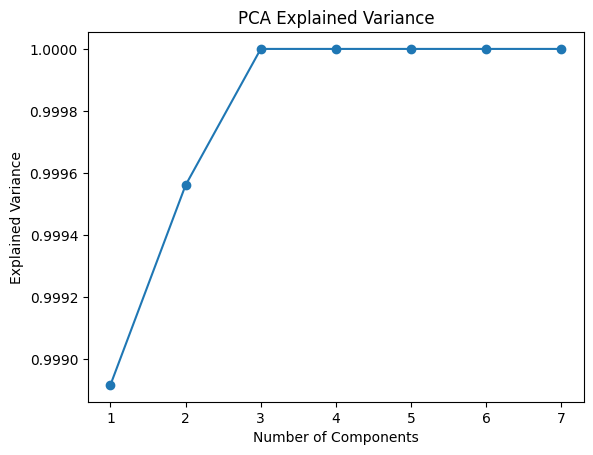

In [55]:
# ¡No modificar! Gráfico de Varianza Explicada por Número de Componentes

explained_variance = []
for i in range(1, 8):
    pca = PCA(n_components=i)
    pca.fit(x_train)
    explained_variance.append(pca.explained_variance_ratio_.sum())

plt.plot(range(1, 8), explained_variance, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance')
plt.title('PCA Explained Variance')
plt.show()

In [56]:
# Elige el número de componentes que consideres adecuado.

pca = PCA(n_components=3) # modelo de PCA con 3 componentes

########################################################################################################################

# ¡No modificar! Esta celda se encarga de transformar los datos con PCA.

pca.fit(x_train)

x_train_pca = pca.transform(x_train)
x_val_pca = pca.transform(x_val)
x_test_pca = pca.transform(x_test)

In [57]:
# Elige el modelo que deseas utilizar. Selecciona los hiperparámetros que consideres. ¿Elegiste la peor combinación anterior?
#     Ejemplo 1: model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE).
#     Ejemplo 2: model = KNeighborsClassifier(n_neighbors=10).

model = RandomForestClassifier(
    n_estimators=500,           #Num. arboles, 100 por defecto
    max_depth=10,               #Profundidad del arbol
    max_features=6,             #Num. maximo de caracteristicas a considerar
    criterion="log_loss",       #Criterio Log Loss, por defecto: Gini
    random_state=RANDOM_STATE,
    n_jobs=-1
)

########################################################################################################################

# ¡No modificar! Este código se encarga de entrenar el modelo y mostrar los resultados en el set de validación.

model.fit(x_train_pca, y_train)

y_val_pca_pred = model.predict(x_val_pca)

print(f'[{model.__class__.__name__}] Validation Classification Report')
print(classification_report(y_val, y_val_pca_pred))

[RandomForestClassifier] Validation Classification Report
              precision    recall  f1-score   support

extreme high       0.34      0.16      0.22       924
 extreme low       0.27      0.92      0.42      2653
        high       0.29      0.00      0.01       462
 high medium       0.11      0.00      0.00       872
         low       0.38      0.01      0.03      1223
  low medium       0.19      0.00      0.01       752
      medium       0.22      0.03      0.05      1414
   very high       0.20      0.10      0.13      1263
    very low       0.33      0.00      0.00       614

    accuracy                           0.27     10177
   macro avg       0.26      0.14      0.10     10177
weighted avg       0.26      0.27      0.16     10177



In [58]:
# ¡No modificar! Esta celda se encarga de mostrar los resultados en el set de test.

y_test_pca_pred = model.predict(x_test_pca)

print(f'[{model.__class__.__name__}] Test Classification Report')
print(classification_report(y_test, y_test_pca_pred))

[RandomForestClassifier] Test Classification Report
              precision    recall  f1-score   support

extreme high       0.33      0.16      0.22      1145
 extreme low       0.28      0.92      0.43      3368
        high       0.00      0.00      0.00       594
 high medium       0.23      0.00      0.01      1035
         low       0.33      0.01      0.02      1444
  low medium       0.21      0.00      0.01       976
      medium       0.22      0.03      0.05      1746
   very high       0.20      0.10      0.13      1573
    very low       0.12      0.00      0.00       841

    accuracy                           0.28     12722
   macro avg       0.22      0.14      0.10     12722
weighted avg       0.24      0.28      0.16     12722



> # ¡NO OLVIDES GUARDAR Y SUBIR EL NOTEBOOK A LA PLATAFORMA CUANDO TERMINES! FORMATO .ipynb